#Imports des librairies et chargement du dataset

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import plotly as pt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df_CduS= pd.read_csv("/content/drive/MyDrive/PARIS 0224 - Data Analyst/Projets/projet3/Vital Stats - Hadi, Sylvain, Henri, Khadija, Erwan/Cancer du Sein/df_CduS.csv", sep = ",")

In [ ]:
df_CduS.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
numeric_columns = df_CS.columns[1:-1]

for c in numeric_columns:
  print(f"Statistiques pour la colonne {c} selon les valeurs de 'diagnosis':\n")
  grouped = df_CduS.groupby("diagnosis")[c].describe(percentiles = np.arange(0, 1, 0.1))
  print(grouped.to_markdown())
  print("\n")


Statistiques pour la colonne radius_mean selon les valeurs de 'diagnosis':

| diagnosis   |   count |    mean |     std |    min |     0% |     10% |    20% |    30% |    40% |    50% |    60% |    70% |    80% |    90% |   max |
|:------------|--------:|--------:|--------:|-------:|-------:|--------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|------:|
| B           |     357 | 12.1465 | 1.78051 |  6.981 |  6.981 |  9.7266 | 10.67  | 11.318 | 11.722 | 12.2   | 12.662 | 13.05  | 13.648 | 14.452 | 17.85 |
| M           |     212 | 17.4628 | 3.20397 | 10.95  | 10.95  | 13.61   | 14.616 | 15.46  | 16.244 | 17.325 | 18.286 | 19.204 | 20.154 | 21.075 | 28.11 |


Statistiques pour la colonne texture_mean selon les valeurs de 'diagnosis':

| diagnosis   |   count |    mean |     std |   min |    0% |    10% |    20% |    30% |    40% |   50% |    60% |    70% |    80% |    90% |   max |
|:------------|--------:|--------:|--------:|------:|------:|-------:|-------:|

In [ ]:
df_CS = df_CduS.copy()

#Distribution

La distribution des valeurs numériques n'est pas très pertinente tant qu'on ne distingue pas les cas bénins des cas malins

On peut donc aller plus loin dans l'observation de la distribution des variables avec un density plot ou un histogramme

Dans les 2 cas nous regardons les distributions en comparant les diagnostics

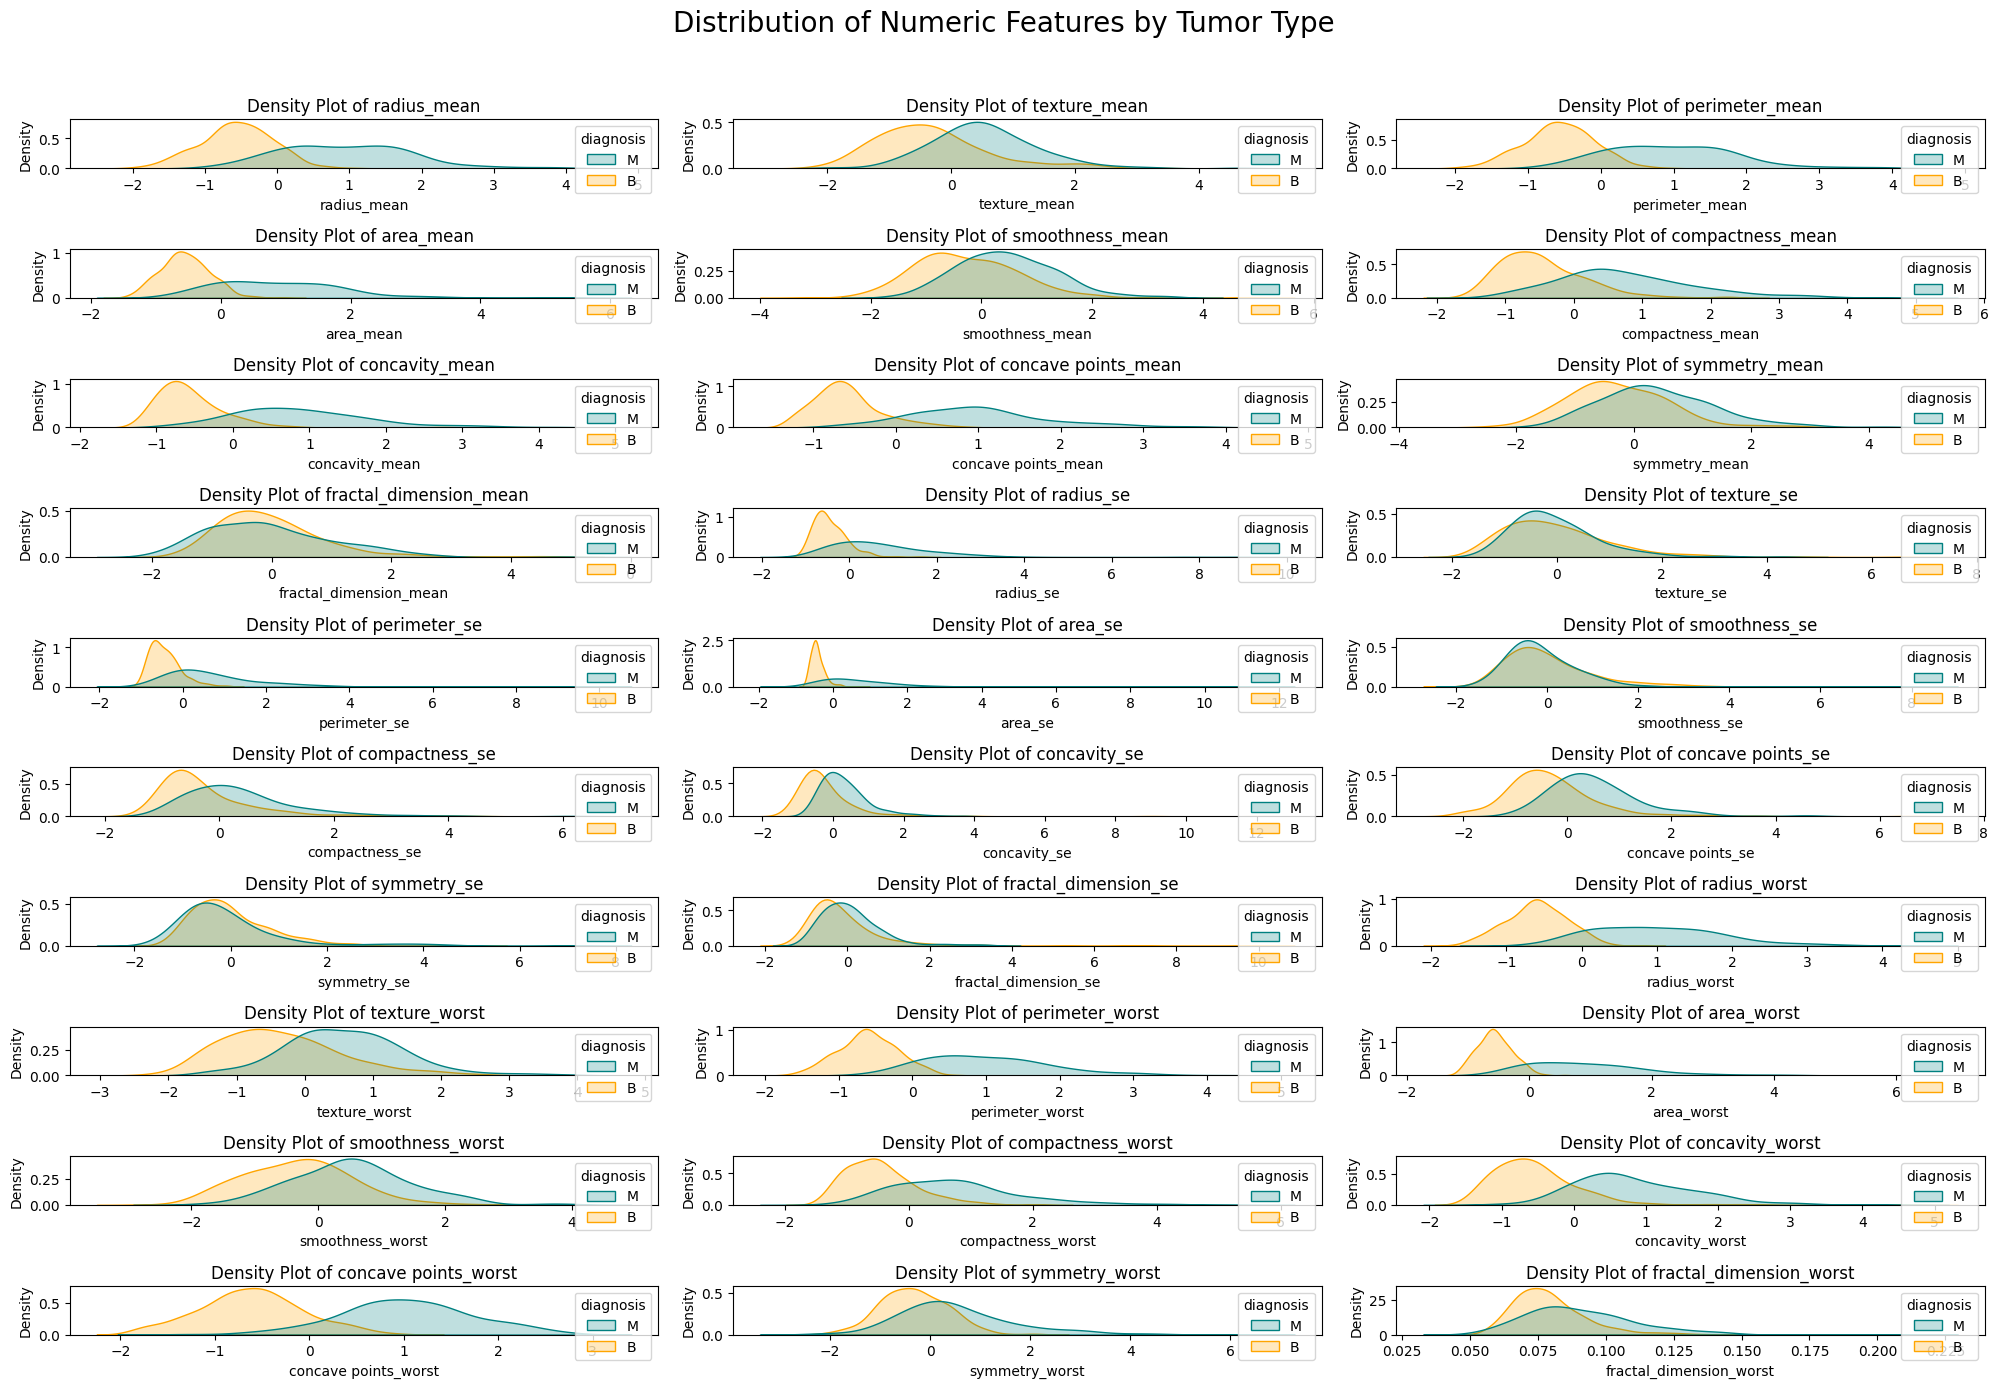

In [ ]:
numeric_columns = df_CS.select_dtypes(include='number').columns

# Créer des tracés de densité
plt.figure(figsize=(20, 15))
for i, column in enumerate(numeric_columns, 1):
    plt.subplot(len(numeric_columns) // 3 + 1, 3, i)
    sns.kdeplot(data=df_CS, x=column, hue='diagnosis', fill=True, common_norm=False, palette=['teal', 'orange'])
    plt.title(f'Density Plot of {column}')

plt.suptitle('Distribution of Numeric Features by Tumor Type', fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Pour certaines caractéristiques, on constate un chevauchement des valeurs entre les diagnostics bénins et malins, ce qui semble invalider la pertinence de ces caractéristiques

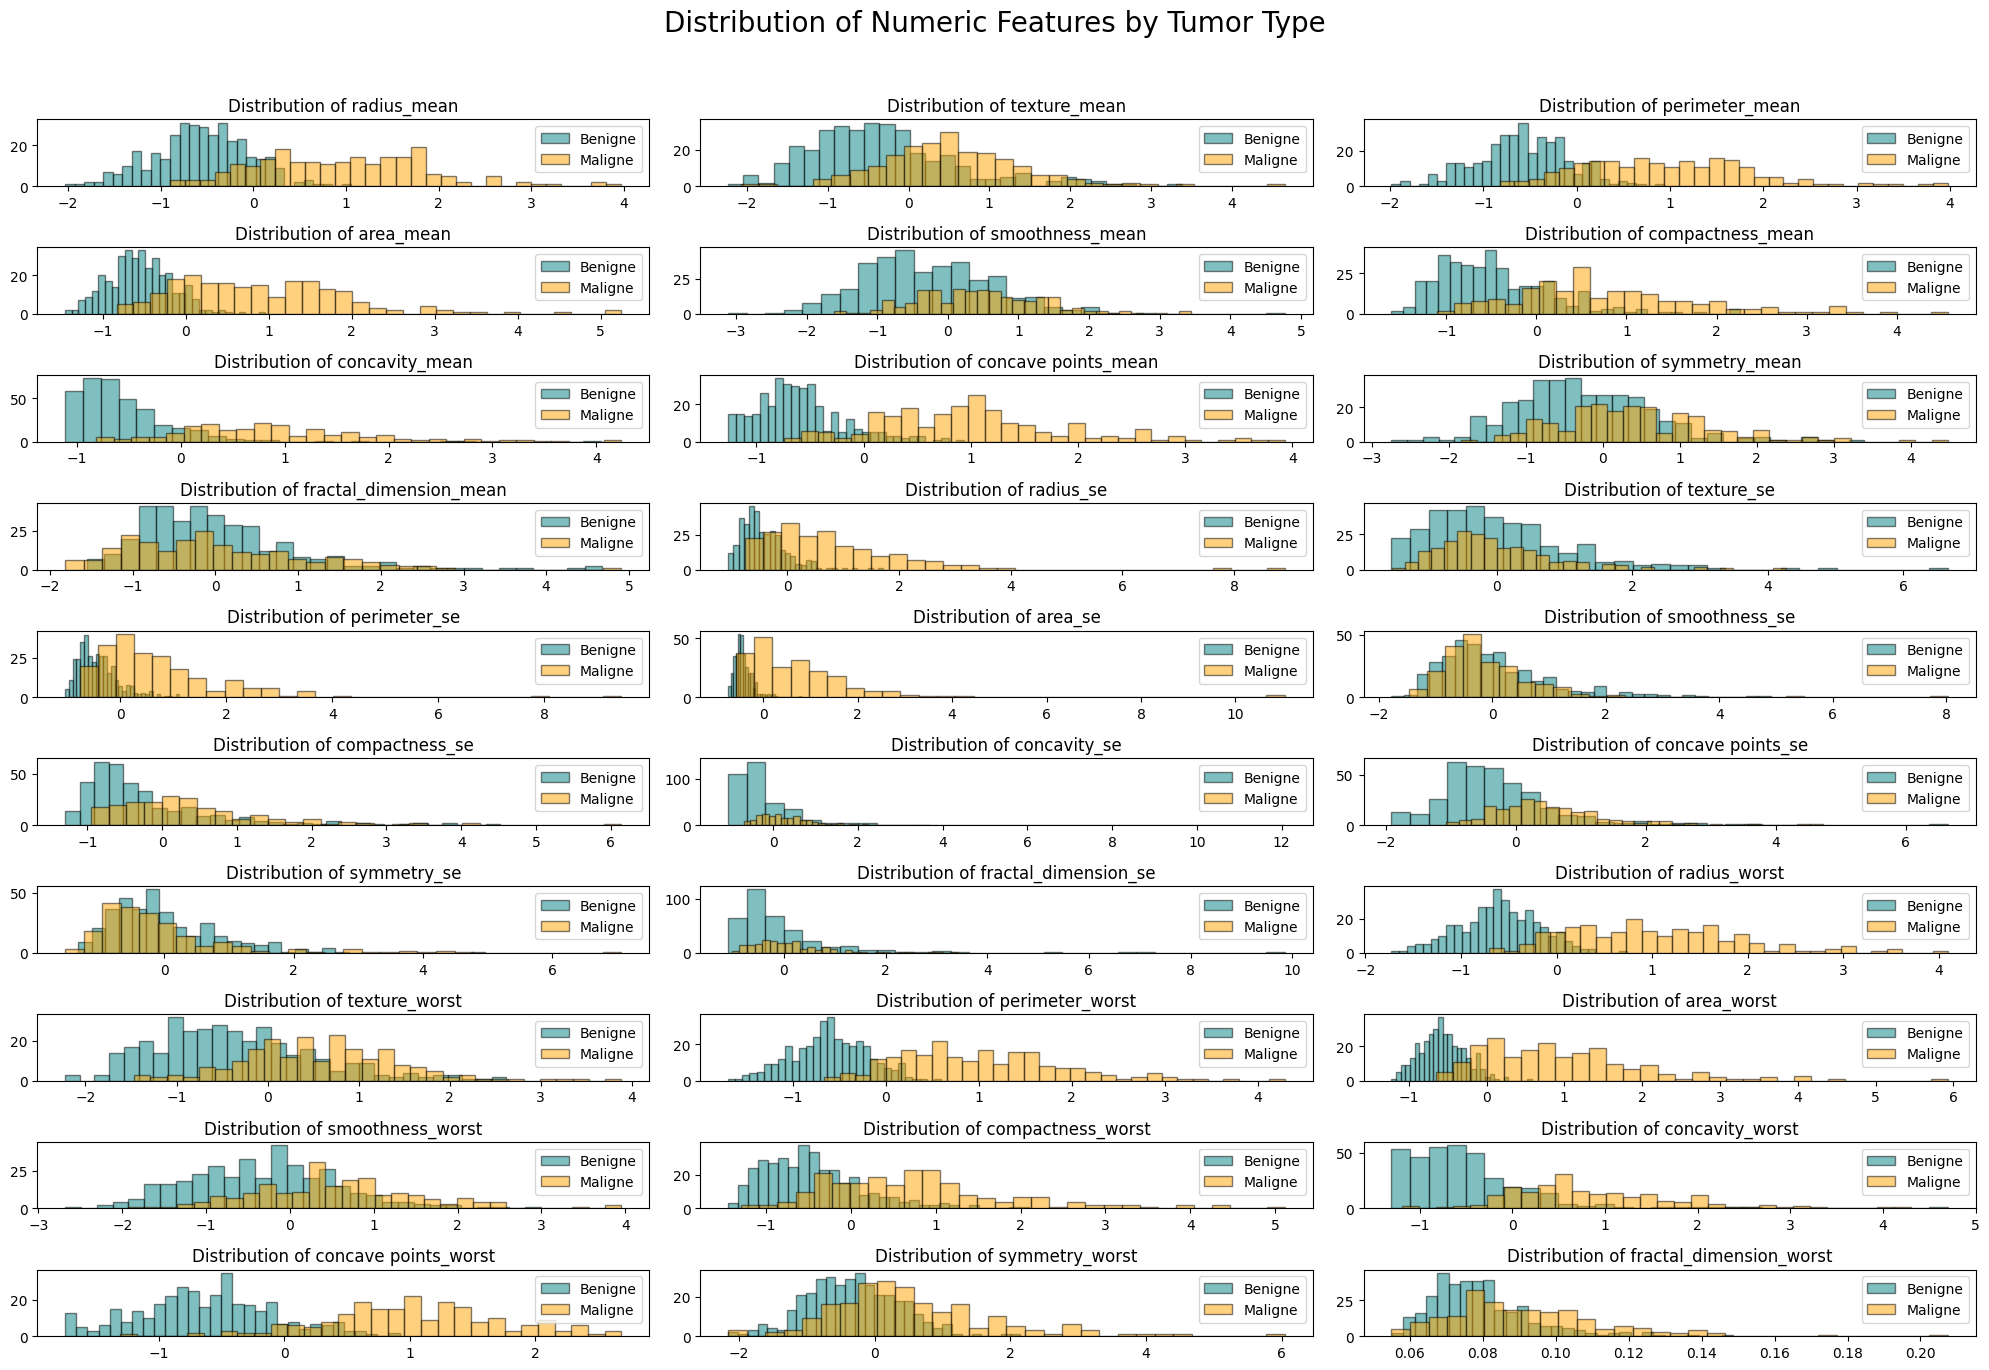

In [ ]:
# Filtrer les données par type de tumeur
benign = df_CS[df_CS['diagnosis'] == 'B']
malignant = df_CS[df_CS['diagnosis'] == 'M']

# Pour chaque colonne numérique dans df_CS
numeric_columns = df_CS.select_dtypes(include='number').columns

# Créer des histogrammes empilés
plt.figure(figsize=(20, 15))
for i, column in enumerate(numeric_columns, 1):
    plt.subplot(len(numeric_columns) // 3 + 1, 3, i)
    plt.hist(benign[column], bins=30, alpha=0.5, label='Benigne', color='teal', edgecolor='black')
    plt.hist(malignant[column], bins=30, alpha=0.5, label='Maligne', color='orange', edgecolor='black')
    plt.title(f'Distribution of {column}')
    plt.legend()

plt.suptitle('Distribution of Numeric Features by Tumor Type', fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()